# Thermodiagrams with MetPy
In this notebook we use MetPY to show the temperature and the humidity profile from a rawinsonde

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import Emagram, SkewT
from metpy.units import units

## Emagram
An emagram is one of the most used thermodynamic diagram. It is used to follow to predict the future state of a parcel of air. The diagram is semilogarithmic and pressure is used as a proxy for height. It contains the dry and the moist adiabats and the isohumes for the water vapor. 

In [173]:
def plot_emagram(p, variables, labels, save_diagram=False):
    '''
    This function plots the temperature and the dew point profiles
    in a emagram T log p diagram
    '''
    # 1. Set up the figure and Emagram object
    fig = plt.figure(figsize=(9, 9))
    ema = Emagram(fig)

    # 3. Plot the environmental profiles
    # Note: MetPy requires (pressure, variable) order for plotting
    num_vars = len(variables)
    colors = ['r', 'g']
    for i in range(num_vars):
        ema.plot(p, variables[i], colors[i], linewidth=2, label=labels[i])
    
    # 5. Add standard thermodynamic background lines
    ema.plot_dry_adiabats(colors='orange', alpha=1.0, linewidths=1)
    ema.plot_moist_adiabats(colors='orange', alpha=1.0, linewidths=1, linestyle=':')
    ema.plot_mixing_lines(colors='blue', alpha=1.0, linewidths=1., linestyle=':') # isohumes (lines of constant water vapor mixing ratio)

    # 6. Customize axes limits and labels
    ema.ax.set_xlim(-60, 40)
    ema.ax.set_ylim(1000, 100) # hPa, Flipped so high pressure is at the bottom

    plt.title('Emagram T ln-P Diagram', fontsize=14, fontweight='bold')
    for label in labels:
        ema.ax.set_xlabel(label)
        
    ema.ax.set_ylabel('Pressure (hPa)')
    ema.ax.legend();
    if (save_diagram == True):
        plt.savefig('data/emagram_Tlnp.jpg')

In [174]:
# 1. Generate or import sample sounding data
# Pressure must go from high (surface) to low (top of atmosphere)
p = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100]) * units.hPa
T = np.array([25, 20, 15, 5, -12, -23, -41, -52, -55, -56, -54]) * units.degC
Td = np.array([18, 14, 8, -2, -22, -35, -55, -65, -73, -80, -85]) * units.degC

In [175]:
variables = []
variables.append(T)
labels = []
labels.append('Temperature')

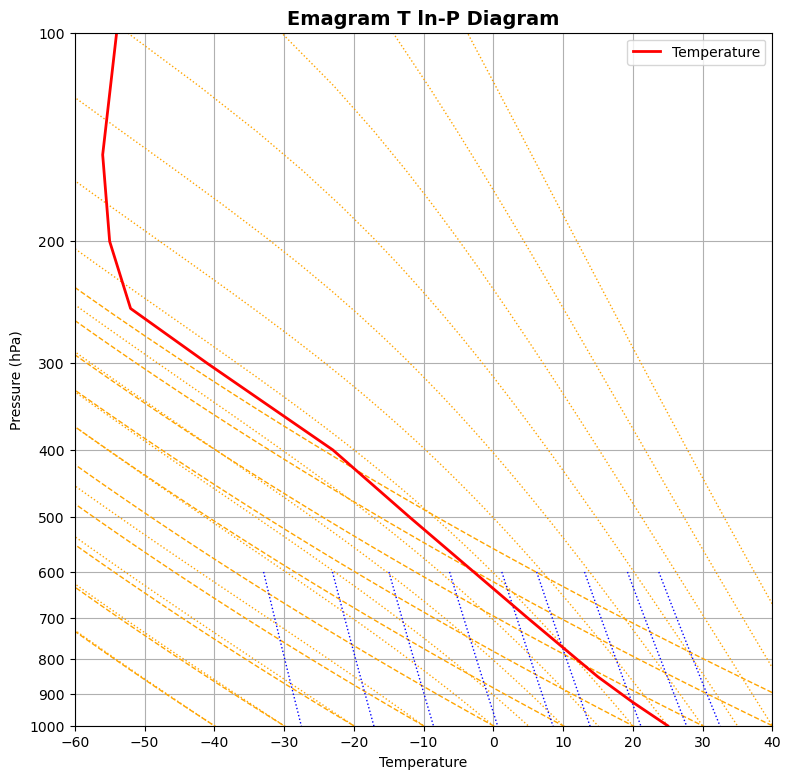

In [176]:
plot_emagram(p, variables, labels)

## The University of Wyoming Atmospheric Science Radiosonde Archive
Rawinsonde data can be dowloaded as CSV files from the [UoW archive](https://weather.uwyo.edu/upperair/sounding.shtml). The same website provides also [surface (in situ)](https://weather.uwyo.edu/surface/surface.shtml) observations from meteorological stations all over the world.   

In [132]:
radiosonde_path = 'data/pratica_di_mare/2026062412-16245.csv'
radiosonde_df = pd.read_csv(radiosonde_path, index_col=0)
radiosonde_df.head(3)

,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
pressure_hPa,,,,,,,,,
1012.0,32,31.8,20.8,20.8,52,52,15.45,250,2.1
1009.0,59,29.4,19.4,19.4,55,55,14.18,246,2.3
1002.0,122,29.0,19.0,19.0,55,55,13.92,238,2.9


In [133]:
rs_pressure = radiosonde_df.index.to_numpy() * units.hPa

In [134]:
rs_temperature = radiosonde_df['temperature_C'].to_numpy() * units.degC

In [135]:
#rs_dew_point = radiosonde_df['dew point temperature_C'].to_numpy() * units.degC

In [178]:
variables = []
variables.append(rs_temperature)
#variables.append(rs_dew_point)
labels = []
labels.append('Temperature')
#labels.append('Dew Point')

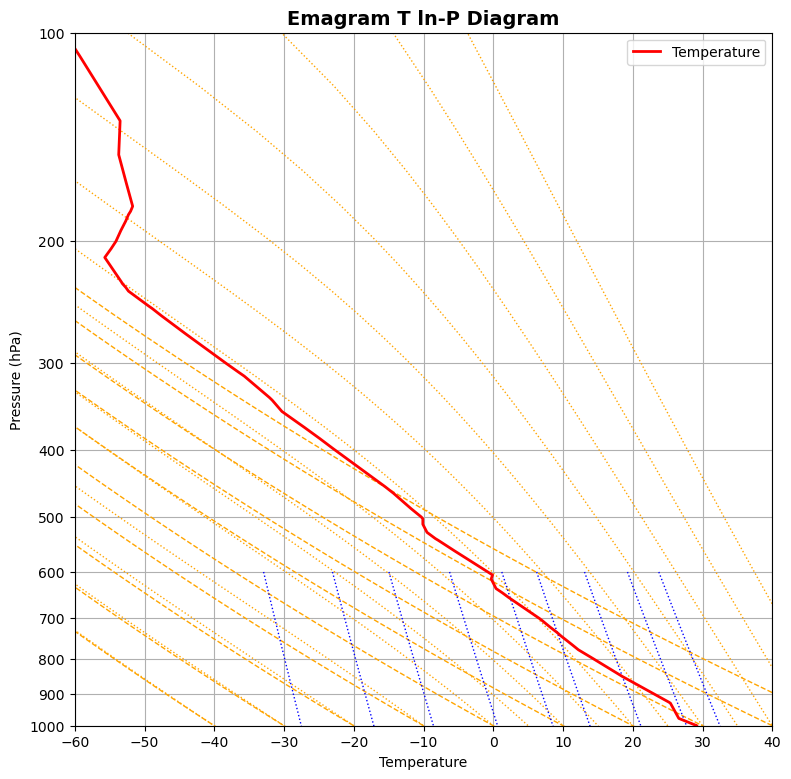

In [179]:
plot_emagram(rs_pressure, variables, labels)

## Skew-T Log-P
The Skew T - Log P diagram is a thermodynamic diagram for the profile of atmospheric temperature as a function of pressure used as a proxy for elevation. The temperature profile provides the state of the atmosphere: the inversion layers, the levels of water vapor condensation and, together with the wind profile at altitude and a terrain model, estimates of possible precipitation and its amount can be made. The graph is semilogarithmic and together with the pressure and temperature coordinates also reports the curves of the dry (yellow line) and wet adiabatics (purple line). In the figure is the graph of the temperature profile collected at 12:00 today 24 June 2026 by the Military Aeronautics in Pratica di Mare, one of the six Italian stations for the collection of atmospheric profiles. A temperature reversal is noted at 950 hPa (500 m.), then the profile follows dry adiabatics, without vapor condensation, and then from 500 hPa (5500 m.), after further reversals, follows a wet adiabaticity, indicating that condensation has occurred. From 200 hPa (12 km) the profile makes a sharp inversion, typical of the stratosphere. Knowing how to read these diagrams is of great importance for weather forecasting, especially in the short term.

Instead of writing our own functions to plot the dry and moist adiabats we can use [MetPY](https://unidata.github.io/MetPy/latest/index.html) that provides functions to do just that.

In [166]:
def plot_skew(p, variables, labels, save_diagram=False):
    '''
    This function plots the temperature and the dew point profiles
    in a skew T log p diagram
    '''
    # 2. Set up the figure and SkewT object
    fig = plt.figure(figsize=(9, 9))
    # 'rotation=45' controls the slant of the temperature lines
    skew = SkewT(fig, rotation=45)

    # 3. Plot the environmental profiles
    # Note: MetPy requires (pressure, variable) order for plotting
    num_vars = len(variables)
    colors = ['r', 'g']
    for i in range(num_vars):
        skew.plot(p, variables[i], colors[i], linewidth=2, label=labels[i])
    #skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')

    # Plot LCL temperature as black dot
    #lcl_pressure, lcl_temperature = mpcalc.lcl(p[0], T[0], Td[0])
    #skew.plot(lcl_pressure, lcl_temperature, 'ko', markerfacecolor='black')
    
    # 4. Plot wind barbs on the right axis
    #skew.plot_barbs(p, u, v)

    # 5. Add standard thermodynamic background lines
    skew.plot_dry_adiabats(colors='orange', alpha=0.4, linewidths=1)
    skew.plot_moist_adiabats(colors='orange', alpha=0.4, linewidths=1, linestyle=':')
    skew.plot_mixing_lines(colors='blue', alpha=0.8, linewidths=1., linestyle=':') # isohumes (lines of constant water vapor mixing ratio)

    # 6. Customize axes limits and labels
    skew.ax.set_xlim(-40, 40)
    skew.ax.set_ylim(1050, 100) # Flipped so high pressure is at the bottom

    plt.title('Skew-T ln P Diagram', fontsize=14, fontweight='bold')
    for label in labels:
        skew.ax.set_xlabel(label)
        
    skew.ax.set_ylabel('Pressure (hPa)')
    skew.ax.legend();
    if (save_diagram == True):
        plt.savefig('data/skewTlnp_diagram.jpg')

In [167]:
variables = []
variables.append(T)
labels = []
labels.append('Temperature')

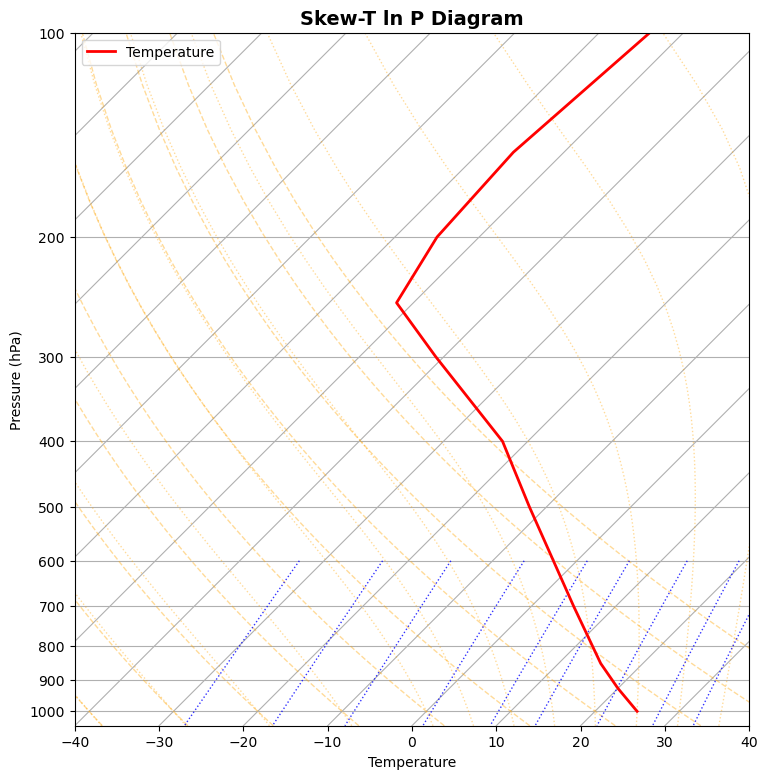

In [168]:
plot_skew(p, variables, labels)

In [171]:
variables = []
variables.append(rs_temperature)
#variables.append(rs_dew_point)
labels = []
labels.append('Temperature')
#labels.append('Dew Point')

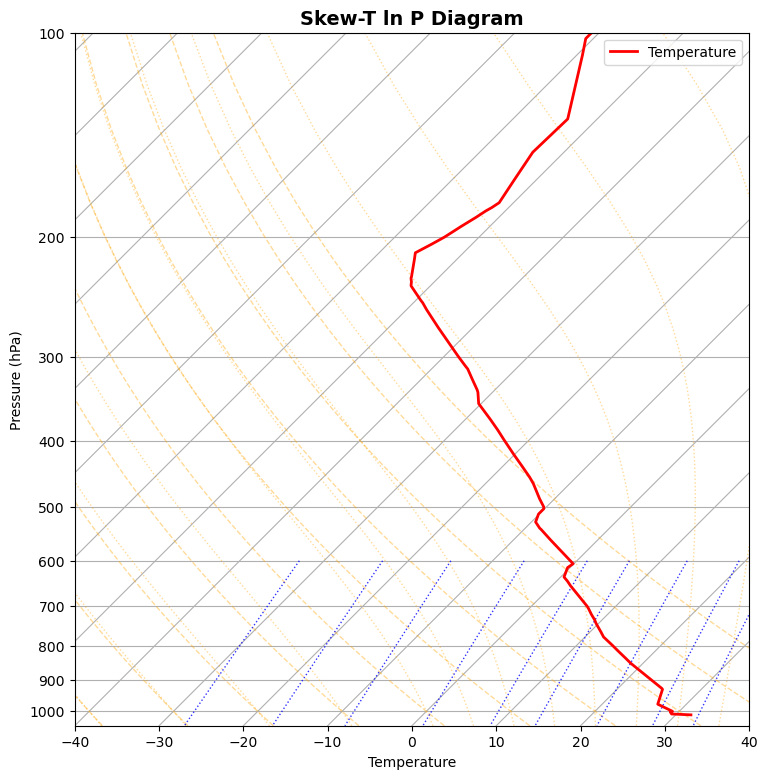

In [172]:
plot_skew(rs_pressure, variables, labels)

## References 
* [Comprehensive Upper-air Observation Network from 1901 to present](https://cds.climate.copernicus.eu/datasets/insitu-comprehensive-upper-air-observation-network)
* [thunderR](https://rawinsonde.com/thunder_app/)
* [University of Wyoming Atmospheric Science Radiosonde Archive](https://weather.uwyo.edu/upperair/sounding.shtml)
* [Aeronautica Militare Italiana - Il Servizio di Radiosondaggio automatico dell'atmosfera](https://www.meteoam.it/it/autosonda)
* [VAISALA - Radiosonde RS41-SG](https://docs.vaisala.com/v/u/B211321EN-L/en-US)
* [Copernicus In-Situ](https://insitu.copernicus.eu/)
* [WMO - Global Observing System](https://wmo.int/activities/global-observing-system-gos/global-observing-system-gos)
* [WMO Oscar Surface](https://oscar.wmo.int/surface/#/)
